In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast

# Load both datasets
digits_df = pd.read_csv("../data/digits.csv")
more_digits_df = pd.read_csv("../data/more_digits.csv")
more_test_df = pd.read_csv("../data/digits_test.csv")

print("digits.csv:")
print(digits_df.head())
print("Shape:", digits_df.shape)

print("\nmore_digits.csv:")
print(more_digits_df.head())
print("Shape:", more_digits_df.shape)

print("\ndigits_test.csv:")
print(more_test_df.head())
print("Shape:", more_test_df.shape)


digits.csv:
   label                                              image
0      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2      6  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4      2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Shape: (12449, 2)

more_digits.csv:
   label                                              image
0      3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1      9  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4      7  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Shape: (15741, 2)

digits_test.csv:
   label                                              image
0      7  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1      3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2      1  [0.0, 

In [14]:
# Original dataset
y_digits = digits_df["label"].to_numpy()
X_digits = np.array(
    digits_df["image"].apply(ast.literal_eval).tolist()
)

# New dataset
y_more = more_digits_df["label"].to_numpy()
X_more = np.array(
    more_digits_df["image"].apply(ast.literal_eval).tolist()
)
y_test = more_test_df["label"].to_numpy()
X_test = np.array(
    more_test_df["image"].apply(ast.literal_eval).tolist()
)


print("digits.csv")
print("X shape:", X_digits.shape)
print("y shape:", y_digits.shape)

print("\nmore_digits.csv")
print("X shape:", X_more.shape)
print("y shape:", y_more.shape)

print("\ndigits_test.csv")
print("X shape:", X_test.shape)
print("y shape:", y_test.shape)

digits.csv
X shape: (12449, 784)
y shape: (12449,)

more_digits.csv
X shape: (15741, 784)
y shape: (15741,)

digits_test.csv
X shape: (2497, 784)
y shape: (2497,)


In [15]:
def describe_dataset(name, X, y):
    print(f"\n--- {name} ---")
    print("Number of samples:", len(X))
    print("Number of pixels:", X.shape[1])
    print("Labels:", np.unique(y))
    print("Min pixel value:", X.min())
    print("Max pixel value:", X.max())
    print("Mean pixel value:", X.mean())
    print("Std pixel value:", X.std())

describe_dataset("digits.csv", X_digits, y_digits)
describe_dataset("more_digits.csv", X_more, y_more)
describe_dataset("digits_test.csv", X_test, y_test)


--- digits.csv ---
Number of samples: 12449
Number of pixels: 784
Labels: [0 1 2 3 4 5 6 7 9]
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.12856833701808879
Std pixel value: 0.3064379734492672

--- more_digits.csv ---
Number of samples: 15741
Number of pixels: 784
Labels: [0 1 2 3 4 5 6 7 8 9]
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.1292576650392736
Std pixel value: 0.3070033961108707

--- digits_test.csv ---
Number of samples: 2497
Number of pixels: 784
Labels: [0 1 2 3 4 5 6 7 8 9]
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.13274833274100342
Std pixel value: 0.31056551381083364


In [16]:
def class_distribution(y):
    labels, counts = np.unique(y, return_counts=True)
    return labels, counts

labels_digits, counts_digits = class_distribution(y_digits)
labels_more, counts_more = class_distribution(y_more)
labels_test, counts_test = class_distribution(y_test)

comparison = pd.DataFrame({

    "digits.csv": pd.Series(y_digits).value_counts().sort_index(),

    "more_digits.csv": pd.Series(y_more).value_counts().sort_index(),

    "digits_test.csv": pd.Series(y_test).value_counts().sort_index()

}).fillna(0).astype(int)

comparison.index.name = "Label"

print(comparison)

       digits.csv  more_digits.csv  digits_test.csv
Label                                              
0            1480             1776              245
1            1685             2022              283
2            1489             1787              258
3            1532             1839              252
4            1460             1752              245
5             271              542              223
6            1479             1775              239
7            1566             1879              257
8               0              585              243
9            1487             1784              252


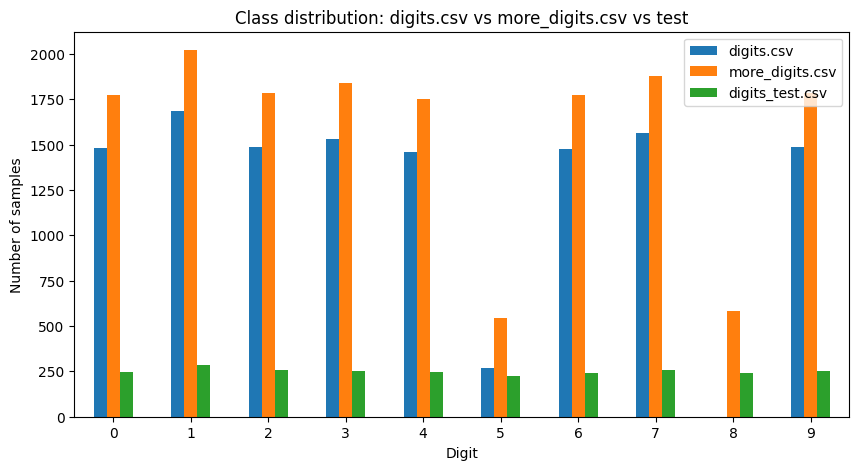

In [17]:
comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Digit")
plt.ylabel("Number of samples")
plt.title("Class distribution: digits.csv vs more_digits.csv vs test")
plt.xticks(rotation=0)
plt.show()

In [18]:
def image_set(X: np.ndarray) -> set[bytes]:
    """Return the set of unique images in X, each image (row) as bytes."""
    return {row.tobytes() for row in X}

set_digits = image_set(X_digits)
set_more = image_set(X_more)
set_test = image_set(X_test)

# Check 1: exact duplicates within each file
print("Duplicates within digits.csv:     ", len(X_digits) - len(set_digits))
print("Duplicates within more_digits.csv:", len(X_more) - len(set_more))
print("Duplicates within digits_test.csv:", len(X_test) - len(set_test))

# Check 2: leakage into the test set
print("\nmore_digits ∩ digits_test:", len(set_more & set_test))
print("digits ∩ digits_test:     ", len(set_digits & set_test))

# Check 3: how much of more_digits is actually new
print("\ndigits ∩ more_digits:     ", len(set_digits & set_more))
print("New images in more_digits:", len(set_more - set_digits))

Duplicates within digits.csv:      0
Duplicates within more_digits.csv: 0
Duplicates within digits_test.csv: 0

more_digits ∩ digits_test: 0
digits ∩ digits_test:      0

digits ∩ more_digits:      3689
New images in more_digits: 12052



Initial Data Exploration

The original digits.csv dataset contains 12,449 samples, while the new more_digits.csv dataset contains 15,741 samples. Both datasets represent 28×28 pixel images, resulting in 784 input features per sample. Pixel values are already scaled between 0 and 1, and the two datasets have very similar overall pixel distributions.

A notable difference is found in the class distribution. The original digits.csv dataset contains no samples of digit 8 and only 271 samples of digit 5, while most other classes contain approximately 1,450–1,700 samples. In contrast, more_digits.csv contains all ten digit classes, including 585 samples of digit 8 and 542 samples of digit 5.

This difference may be particularly relevant when comparing the performance of Exercises 2 and 3. A model trained only on digits.csv has no training examples from class 8 and relatively few examples from class 5. The additional data in more_digits.csv therefore not only increases the total amount of training data, but also changes the class coverage and provides examples from a previously unseen class. This is an important factor to consider when analyzing why performance changes in Exercise 3, independently of changes to the model or training techniques.

## Findings (notes)

### Class shares: training vs. test

| Class | `digits.csv` | `more_digits.csv` | `digits_test.csv` |
|---|---|---|---|
| 5 | 271 (2.2 %) | 542 (3.4 %) | 223 (8.9 %) |
| 8 | 0 (0.0 %) | 585 (3.7 %) | 243 (9.7 %) |
| Others | ~11.7–13.5 % each | ~11.1–12.8 % each | ~9.6–11.3 % each |

- The test set is roughly balanced (~10 % per class); both training sets are not.
- Classes 5 and 8 together: 18.7 % of the test set, but only 7.2 % of `more_digits.csv`.
- → Class prior shift between learning data and "production" data.

### Upper bound for Exercise 2

- A model trained on `digits.csv` has never seen class 8, so every 8 in the test set is misclassified.
- Max. test accuracy = (2497 − 243) / 2497 = 2254 / 2497 ≈ **90.3 %**, even with every other class perfect.
- → The 98 % target is unreachable with `digits.csv` alone, regardless of model or hyperparameters.

### What 98 % requires in Exercise 3

- Worked example: if the eight other classes (81.3 % of test) reach 99 % recall, they contribute ≈ 80.5 points.
- The remaining ≈ 17.5 points must come from classes 5 and 8 (18.7 % of test) → recall ≈ **93.5 %** on 5 and 8.
- → Track per-class recall, not only overall accuracy. The validation split inherits the training imbalance, so it under-represents 5 and 8 compared with the test set.

### Data integrity checks (exact duplicates, via `tobytes()`)

| Check | Result |
|---|---|
| Duplicates within `digits.csv` / `more_digits.csv` / `digits_test.csv` | 0 / 0 / 0 |
| `more_digits.csv` ∩ `digits_test.csv` | 0 |
| `digits.csv` ∩ `digits_test.csv` | 0 |
| `digits.csv` ∩ `more_digits.csv` | 3,689 |
| Images in `more_digits.csv` not in `digits.csv` | 12,052 (76.6 %) |

- No leakage into the test set → test accuracy is a valid estimate of "production" performance.
- `more_digits.csv` is **not** a superset of `digits.csv`: ~30 % of `digits.csv` reappears, the rest of `more_digits.csv` is new.
- Union without duplicates: 12,449 + 12,052 = 24,501 unique images → candidate technique for (b).
- Caveat: only *exact* duplicates are detected; shifted or re-scaled copies of the same digit would not be caught.

### Candidate "other factors" for (c)

- Class 8 present in the learning data for the first time.
- Twice as many examples of class 5.
- ~26 % more samples, of which ~77 % are new images.
